In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/telco-churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Create local SQLite database
conn = sqlite3.connect('telco.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

print("Database created successfully!")
print("Total customers:", len(df))

Database created successfully!
Total customers: 7032


In [2]:
# Business Question 1: What is the overall retention rate by contract type?
query = """
SELECT 
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    SUM(CASE WHEN Churn = 'No' THEN 1 ELSE 0 END) as retained,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) as churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC
"""

result = pd.read_sql_query(query, conn)
print(result)

         Contract  total_customers  churned  retained  churn_rate
0  Month-to-month             3875     1655      2220        42.7
1        One year             1472      166      1306        11.3
2        Two year             1685       48      1637         2.8


In [3]:
# Business Question 2: Which tenure groups have the highest churn?
query2 = """
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END as tenure_group,
    COUNT(*) as total_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) as churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

   tenure_group  total_customers  churn_rate
0   0-12 months             2175        47.7
1  13-24 months             1024        28.7
2  25-48 months             1594        20.4
3    49+ months             2239         9.5


In [4]:
# Business Question 3: What services do churned vs retained users use differently?
query3 = """
SELECT 
    InternetService,
    COUNT(*) as total_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) as churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

  InternetService  total_customers  churn_rate
0     Fiber optic             3096        41.9
1             DSL             2416        19.0
2              No             1520         7.4


In [5]:
# Create tenure cohort groups
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Create cohort retention matrix
cohort_data = df.groupby(['tenure_group', 'Contract'])['Churn'].apply(
    lambda x: round(100 * (x == 'No').sum() / len(x), 1)
).unstack()

print(cohort_data)

Contract      Month-to-month  One year  Two year
tenure_group                                    
0-12 months             48.6      89.4     100.0
13-24 months            62.3      91.9     100.0
25-48 months            67.1      89.4      97.8
49+ months              74.0      87.1      96.7


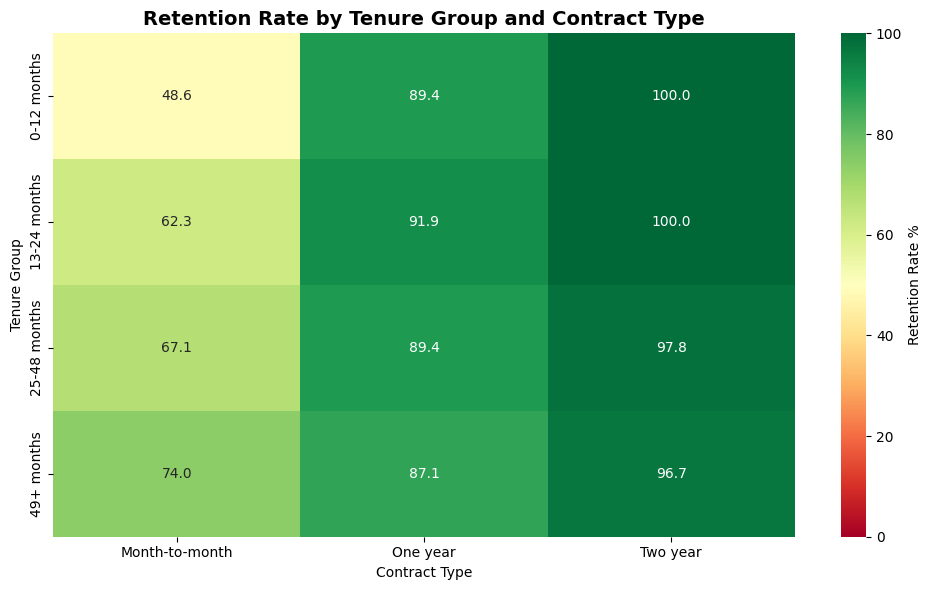

In [7]:
# Draw cohort retention heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Set correct order for tenure groups
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
cohort_data = cohort_data.reindex(tenure_order)

sns.heatmap(cohort_data, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlGn',
            vmin=0, 
            vmax=100,
            ax=ax,
            cbar_kws={'label': 'Retention Rate %'})

ax.set_title('Retention Rate by Tenure Group and Contract Type', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Tenure Group')

plt.tight_layout()
plt.savefig('charts/retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

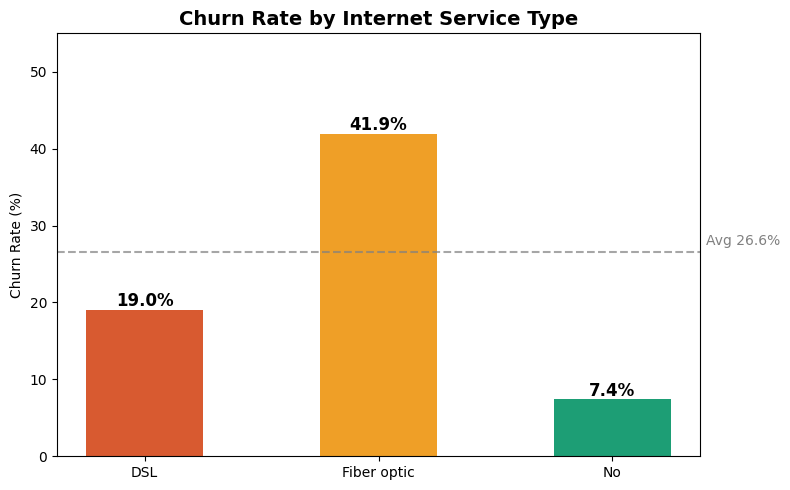

In [8]:
# Visualize churn rate by internet service type
fig, ax = plt.subplots(figsize=(8, 5))

service_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: round(100 * (x == 'Yes').sum() / len(x), 1)
).reset_index()
service_churn.columns = ['InternetService', 'ChurnRate']

colors = ['#D85A30', '#EF9F27', '#1D9E75']
bars = ax.bar(service_churn['InternetService'], 
              service_churn['ChurnRate'],
              color=colors, width=0.5)

# Add labels above bars
for bar, rate in zip(bars, service_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{rate}%',
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('Churn Rate by Internet Service Type', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.axhline(y=26.6, color='gray', linestyle='--', alpha=0.7)
ax.text(2.4, 27.5, 'Avg 26.6%', color='gray', fontsize=10)

plt.tight_layout()
plt.savefig('charts/churn_by_service.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings & Business Recommendations

### Finding 1: New Users Are the Highest Risk Group
- Users in their first 12 months churn at 47.7% — nearly 1 in 2 leave
- **Recommendation:** Implement a structured 12-month onboarding program 
  with check-ins at months 1, 3, 6, and 12

### Finding 2: Month-to-Month Contract is the Core Problem
- New month-to-month users have only 48.6% retention — the lowest of all segments
- Two-year contract users retain at 97-100% regardless of tenure
- **Recommendation:** Offer a discounted first-year rate to incentivize 
  new users to commit to annual contracts

### Finding 3: Fiber Optic Users Are Underserved
- Fiber optic churn rate (41.9%) is 2× higher than DSL (19.0%)
- These are the highest-paying users — losing them is costly
- **Recommendation:** Conduct user research on Fiber optic satisfaction 
  and introduce a premium loyalty program

### Summary: Priority Action Plan
| Priority | Action | Target Segment |
|----------|--------|----------------|
| 1 | 12-month onboarding program | New users (0-12 months) |
| 2 | Contract upgrade incentives | Month-to-month users |
| 3 | Fiber optic loyalty program | High-spend users |